## Introduction

## Preparation

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# Download dataset
# path = "mdmahfuzsumon/large-scale-financial-fraud-dataset"
path = r"C:\Users\Pablo\Documents\Data_projects\2604_predictive_model_financial_fraud\improved_fraud_dataset.csv"
df = pd.read_csv(path)

In [3]:
# Visualize dataframe information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14  device_type        

In [4]:
# Show dataframe shape
print(f"Loaded Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset: 1000000 rows, 24 columns


In [5]:
# Show dataframe first rows
print(df.head(3))

     organization transaction_id               user_id  user_account_age_days  \
0  FinovaTech_000    TXN00000044  FinovaTech_000_U0000                   1670   
1  FinovaTech_000    TXN00000004  FinovaTech_000_U0000                   1670   
2  FinovaTech_000    TXN00000033  FinovaTech_000_U0000                   1670   

   kyc_verified payment_method card_type  transaction_amount currency  \
0             1          bkash     debit             1553.81      BDT   
1             1          bkash     debit              136.49      BDT   
2             1           card    credit             3432.40      BDT   

   fee_amount  ... device_type operating_system browser merchant_category  \
0       31.08  ...      mobile          Windows  Safari           fashion   
1        2.73  ...     desktop          Android    Edge           grocery   
2       68.65  ...      tablet              iOS  Safari       electronics   

  transaction_type otp_used is_fraud hour is_night  time_diff  
0        

In [6]:
# Show dataframe last rows
print(df.tail(3))

          organization transaction_id               user_id  \
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
999997                    303             0           bank     debit   
999998                    303             1           bank    credit   
999999                    303             1          bkash    credit   

        transaction_amount currency  fee_amount  ... device_type  \
999997              234.90      BDT        4.70  ...      mobile   
999998             1104.45      BDT       22.09  ...     desktop   
999999              714.08      BDT       14.28  ...      mobile   

       operating_system browser merchant_category transaction_type otp_used  \
999997              iOS  Safari           fashion         purchase        0   
999998          Windows  Ch

In [7]:
print(df)

          organization transaction_id               user_id  \
0       FinovaTech_000    TXN00000044  FinovaTech_000_U0000   
1       FinovaTech_000    TXN00000004  FinovaTech_000_U0000   
2       FinovaTech_000    TXN00000033  FinovaTech_000_U0000   
3       FinovaTech_000    TXN00000050  FinovaTech_000_U0000   
4       FinovaTech_000    TXN00000047  FinovaTech_000_U0000   
...                ...            ...                   ...   
999995  FinovaTech_199    TXN00999994  FinovaTech_199_U0099   
999996  FinovaTech_199    TXN00999962  FinovaTech_199_U0099   
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
0                        1670             1          bkash     debit   
1                        1670             1          bkash     debit   
2                        16

In [8]:
print(df['transaction_timestamp'].head())

0    2024-01-26 08:20:20
1    2024-02-15 06:00:28
2    2024-02-24 19:47:58
3    2024-03-07 19:30:22
4    2024-03-12 12:58:07
Name: transaction_timestamp, dtype: object


## Data cleaning

In [9]:
# ========================
# Cleaning headers
# ========================
print(df.columns)

Index(['organization', 'transaction_id', 'user_id', 'user_account_age_days',
       'kyc_verified', 'payment_method', 'card_type', 'transaction_amount',
       'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week',
       'city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour',
       'is_night', 'time_diff'],
      dtype='object')


In [10]:
# ===================================
# Cleaning numerical columns
# ===================================
numeric = df[['user_account_age_days', 'transaction_amount', 'fee_amount', 'hour', 'time_diff']]
print(numeric.head(3))

   user_account_age_days  transaction_amount  fee_amount  hour  time_diff
0                   1670             1553.81       31.08     8        0.0
1                   1670              136.49        2.73     6  1719608.0
2                   1670             3432.40       68.65    19   827250.0


- Headers and numerical columns are clean

In [11]:
# =====================================
# Cleaning categorial typos
# =====================================

categorical = df[['organization', 'transaction_id', 'user_id', 'payment_method', 'card_type', 'currency', 'day_of_week','city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type']]
# Verify that there are no duplicates in the categorical columns
print(f"There are {categorical.duplicated().sum()} duplicates.")
print()

for col in categorical:
    print(col)
    print(categorical[col].unique())
    print()


There are 0 duplicates.

organization
['FinovaTech_000' 'FinovaTech_001' 'FinovaTech_002' 'FinovaTech_003'
 'FinovaTech_004' 'FinovaTech_005' 'FinovaTech_006' 'FinovaTech_007'
 'FinovaTech_008' 'FinovaTech_009' 'FinovaTech_010' 'FinovaTech_011'
 'FinovaTech_012' 'FinovaTech_013' 'FinovaTech_014' 'FinovaTech_015'
 'FinovaTech_016' 'FinovaTech_017' 'FinovaTech_018' 'FinovaTech_019'
 'FinovaTech_020' 'FinovaTech_021' 'FinovaTech_022' 'FinovaTech_023'
 'FinovaTech_024' 'FinovaTech_025' 'FinovaTech_026' 'FinovaTech_027'
 'FinovaTech_028' 'FinovaTech_029' 'FinovaTech_030' 'FinovaTech_031'
 'FinovaTech_032' 'FinovaTech_033' 'FinovaTech_034' 'FinovaTech_035'
 'FinovaTech_036' 'FinovaTech_037' 'FinovaTech_038' 'FinovaTech_039'
 'FinovaTech_040' 'FinovaTech_041' 'FinovaTech_042' 'FinovaTech_043'
 'FinovaTech_044' 'FinovaTech_045' 'FinovaTech_046' 'FinovaTech_047'
 'FinovaTech_048' 'FinovaTech_049' 'FinovaTech_050' 'FinovaTech_051'
 'FinovaTech_052' 'FinovaTech_053' 'FinovaTech_054' 'FinovaTech_0

In [12]:
# =====================================
# Cleaning booleans
# =====================================

# Verify that there are no mixed booleans columns
booleans = df[['kyc_verified', 'otp_used', 'is_fraud', 'is_night']]

for col in booleans:
    print(col)
    print(booleans[col].unique())
    print()

kyc_verified
[1 0]

otp_used
[1 0]

is_fraud
[0 1]

is_night
[0 1]



In [13]:
# =====================================
# Date parsing
# =====================================

# Check the type
print(df['transaction_timestamp'].dtype)

# Change of column type for date
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], yearfirst=True,errors='coerce')

print()
print("Fix applied")
print(df['transaction_timestamp'].dtype)

object

Fix applied
datetime64[ns]


## Exploratory Data Analysis

is_fraud
0    908290
1     91710
Name: is_fraud, dtype: int64



C:\Users\Pablo\AppData\Local\Temp\ipykernel_2244\566693496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


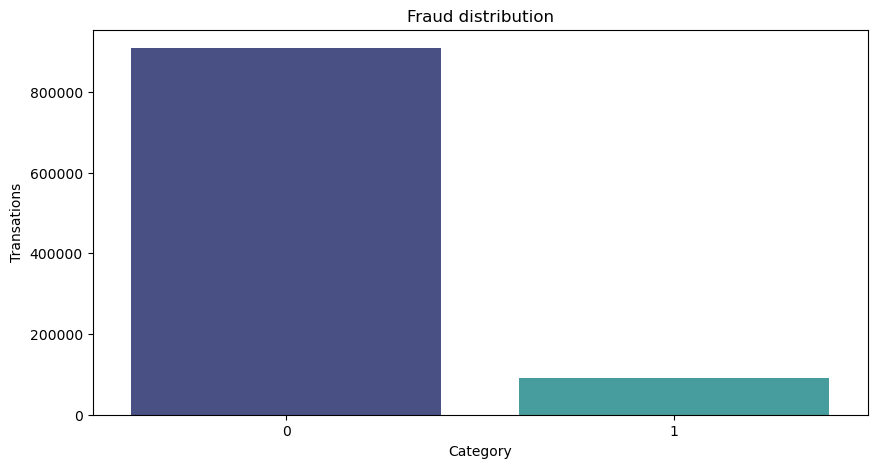

In [14]:
print(df.groupby(['is_fraud'])['is_fraud'].count())
print()
# Plot fraud distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='is_fraud',
    palette="mako"
)

plt.title("Fraud distribution")
plt.xlabel("Category")
plt.ylabel("Transations")
plt.show()

### Fraud vs Numerical features

In [15]:
fraud_vs_amount = df.groupby(['is_fraud'])['transaction_amount'].mean()

print(fraud_vs_amount)

is_fraud
0    2001.396134
1    2022.402542
Name: transaction_amount, dtype: float64


In [16]:
fraud_vs_time_diff = df.groupby(['is_fraud'])['time_diff'].mean()

print(fraud_vs_time_diff)

is_fraud
0    1.220210e+06
1    1.167106e+06
Name: time_diff, dtype: float64


In [17]:
fraud_vs_account_long = df.groupby(['is_fraud'])['user_account_age_days'].mean()

print(fraud_vs_account_long)

is_fraud
0    1004.989733
1    1006.694199
Name: user_account_age_days, dtype: float64


### Fraud vs Categorical features

In [18]:
fraud_vs_pmethod = df[df['is_fraud'] == 1].groupby(['payment_method'])['payment_method'].count().sort_values(ascending=False)

print(fraud_vs_pmethod)

payment_method
card     23057
bkash    23010
nagad    22846
bank     22797
Name: payment_method, dtype: int64


In [19]:
fraud_vs_card = df[df['is_fraud'] == 1].groupby(['card_type'])['card_type'].count().sort_values(ascending=False)

print(fraud_vs_card)

card_type
debit     46037
credit    45673
Name: card_type, dtype: int64


In [20]:
fraud_vs_device = df[df['is_fraud'] == 1].groupby(['device_type'])['device_type'].count().sort_values(ascending=False)

print(fraud_vs_device)

device_type
tablet     30615
desktop    30573
mobile     30522
Name: device_type, dtype: int64


In [21]:
fraud_vs_merchant = df[df['is_fraud'] == 1].groupby(['merchant_category'])['merchant_category'].count().sort_values(ascending=False)

print(fraud_vs_merchant)

merchant_category
fashion        23070
grocery        23064
travel         23046
electronics    22530
Name: merchant_category, dtype: int64


In [22]:
fraud_vs_transaction = df[df['is_fraud'] == 1].groupby(['transaction_type'])['transaction_type'].count().sort_values(ascending=False)

print(fraud_vs_transaction)

transaction_type
withdrawal    30596
purchase      30577
transfer      30537
Name: transaction_type, dtype: int64


In [23]:
fraud_vs_city = df[df['is_fraud'] == 1].groupby(['city'])['city'].count().sort_values(ascending=False)

print(fraud_vs_city)

city
Chittagong    23077
Rajshahi      22970
Dhaka         22895
Khulna        22768
Name: city, dtype: int64


In [24]:
fraud_vs_day = df[df['is_fraud'] == 1].groupby(['day_of_week'])['day_of_week'].count().sort_values(ascending=False)

print(fraud_vs_day)

day_of_week
Tuesday      13272
Wednesday    13229
Thursday     13217
Monday       13185
Friday       13055
Sunday       13013
Saturday     12739
Name: day_of_week, dtype: int64


In [26]:
# Plot fraud by day
plt.figure(figsize=(9,4.5))

sns.lineplot(x=fraud_vs_day.sort_values(by='Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday').index,
             y=fraud_vs_day.values            
)

plt.title("Fraud by hour")
plt.xlabel('Hours')
plt.ylabel('Transactions')
plt.show()

TypeError: Series.sort_values() got an unexpected keyword argument 'by'

<Figure size 900x450 with 0 Axes>

In [27]:
fraud_vs_opsystem = df[df['is_fraud'] == 1].groupby(['operating_system'])['operating_system'].count().sort_values(ascending=False)

print(fraud_vs_opsystem)

operating_system
Windows    30739
iOS        30677
Android    30294
Name: operating_system, dtype: int64


In [28]:
fraud_vs_browser = df[df['is_fraud'] == 1].groupby(['browser'])['browser'].count().sort_values(ascending=False)

print(fraud_vs_browser)

browser
Chrome    30617
Edge      30570
Safari    30523
Name: browser, dtype: int64


### Fraud vs Boolean Features

In [29]:
# Fraud vs boolean
# ['kyc_verified', 'otp_used', 'is_fraud', 'is_night']

In [ ]:
fraud_kyc = df[df['is_fraud'] == 1].groupby(['kyc_verified'])['kyc_verified'].count()
print(fraud_kyc)

print()

fraud_kyc_rate = fraud_kyc / fraud_kyc.sum() * 100
print(fraud_kyc_rate)

kyc_verified
0    18413
1    73297
Name: kyc_verified, dtype: int64

kyc_verified
0    20.077418
1    79.922582
Name: kyc_verified, dtype: float64


In [37]:
fraud_otp = df[df['is_fraud'] == 1].groupby(['otp_used'])['otp_used'].count()
print(fraud_otp)

print()

fraud_otp_rate = fraud_otp / fraud_otp.sum() * 100
print(fraud_otp_rate)

otp_used
0    27645
1    64065
Name: otp_used, dtype: int64

otp_used
0    30.143932
1    69.856068
Name: otp_used, dtype: float64


In [38]:
fraud_vs_night = df[df['is_fraud'] == 1].groupby(['is_night'])['is_night'].count()
print(fraud_vs_night)

print()

fraud_vs_night_rate = fraud_vs_night / fraud_vs_night.sum() * 100
print(fraud_vs_night_rate)

is_night
0     4325
1    87385
Name: is_night, dtype: int64

is_night
0     4.715952
1    95.284048
Name: is_night, dtype: float64


### Fraud vs Time

In [33]:
fraud_vs_hour = df[df['is_fraud'] == 1].groupby(['hour'])['hour'].count()

print(fraud_vs_hour)

hour
0     12543
1     12598
2     12415
3     12419
4     12382
5     12476
6       262
7       235
8       241
9       276
10      247
11      251
12      224
13      252
14      280
15      280
16      238
17      259
18      252
19      251
20      268
21      278
22      231
23    12552
Name: hour, dtype: int64


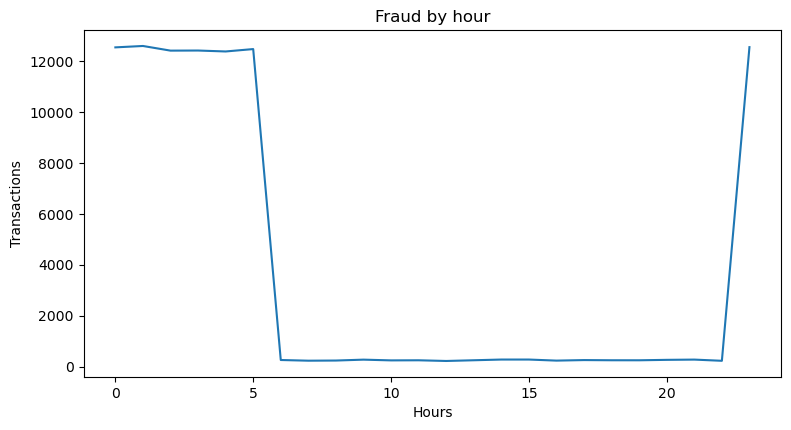

In [34]:
# Plot fraud by hour
plt.figure(figsize=(9,4.5))

sns.lineplot(x=fraud_vs_hour.index,
             y=fraud_vs_hour.values            
)

plt.title("Fraud by hour")
plt.xlabel('Hours')
plt.ylabel('Transactions')
plt.show()

## Probability

¿Qué probabilidad hay que una un fraude ocurra en una cuenta con kyc?

¿Qué probabilidad hay de fraude en una transaccion con otp?

¿Qué probabilidad es que exista fraude en la noche?

¿Qué probabilidad hay de un fraude utilizando tarjeta?

### Hipotesis

H0 : No hay diferencia entre un cliente con kyc verificado

H1 : Sí hay diferencia entre un cliente con kyc verificado

H0 : No hay diferencia entre una operación con otp

H1 : Si hay diferencia entre una operación con otp

H0: No hay diferencia entre fraudes de día o de noche

H1: Si hay diferencia entre fraudes de día o de noche

H0: No hay diferencia entre los fraudes con tarjeta respecto a los demás metodos de pago

H1: Sí hay diferencia entre los fraudes con tarjeta respecto a los demás metodos de pago

Hipótesis nula:
 - Los ingresos promedio de los usuarios de los planes Ultimate y Surf son iguales.
 
 Hipotesis alternativa: 
 - Los ingresos promedio de los usuarios de los planes Ultimate y Surf son diferentes.

In [ ]:
# Prueba las hipótesis
#series de total de ingresos por plan
serie_income_ultimate = df_consumption_merge[df_consumption_merge['plan'] == 'ultimate']['total_income']
serie_income_surf = df_consumption_merge[df_consumption_merge['plan'] == 'surf']['total_income']

#Promedio de las muestras
mean_income_ultimate = serie_income_ultimate.mean()
mean_income_surf = serie_income_surf.mean()
print(mean_income_ultimate, 'promedio de la muestra del plan ultimate')
print(mean_income_surf, 'promedio de la muestra del plan surf')
print()

alpha = 0.05

#Realiza la prueba
results = st.ttest_1samp(serie_income_ultimate,mean_income_surf)

#Valor p resultante
print('valor p:', results.pvalue)

# comparar el valor p con el umbral
if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

## Prepation before modeling

In [ ]:
# Plot correlation heatmap
corr = df[numeric].corr()

plt.figure(figsize=(8,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Sort features by correlation importance
features_corr = corr['label_multiclass'].drop('label_multiclass').sort_values(key=abs, ascending=False)
print(features_corr.to_string())

## Modeling

## Conclusions